**Fundamentals of Machine Learning - Exercise 3** 💪
---
---
### 🎯 Aim of the Exercise

🧩 understand and apply K-means clustering,  
📉 choose the number of clusters using the elbow method,  
📏 evaluate clusters using the silhouette index,  
🌍 interpret clustering results on two real-world datasets.  

In **supervised learning**, a model learns from input features `X` and known target values `y`.

In **unsupervised learning**, no target is supplied. The algorithm searches for structure in the input data `X`.

**Clustering** assigns each point to a **cluster** so that points in the same cluster are more similar to each other than to points elsewhere. It is used for exploration, segmentation, compression, and as a preprocessing step.

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
np.set_printoptions(legacy='1.25')

Text(0.5, 1.0, 'Synthetic data: three Gaussian blobs')

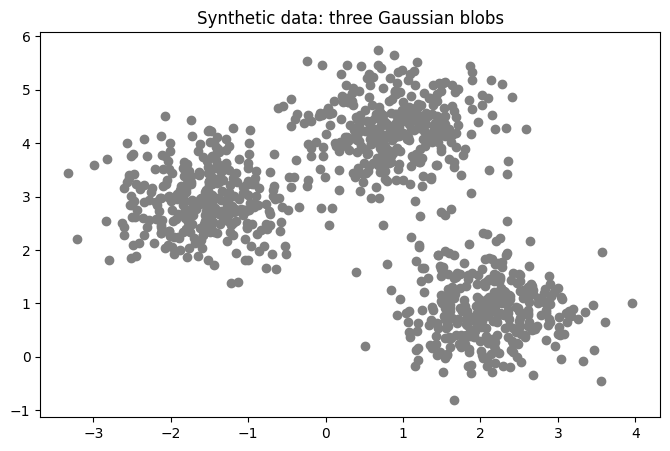

In [75]:
# Generate 1000 points in 2D distributed in 3 clusters
X, _ = make_blobs(n_samples=1000, centers=3, cluster_std=0.60, random_state=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X[:, 0], X[:, 1], color='grey')
ax.set_title("Synthetic data: three Gaussian blobs")

> **Note:** Here we use **synthetic blob data** where the true number of groups is known. On real data you rarely have that ground truth.

## K-Means clustering

**Intuition:**   
- Pick **k** cluster centers (**centroids**).   
- Repeat: (1) assign each point to the nearest centroid, (2) move each centroid to the mean of its assigned points.   
- Stop when assignments stabilize.

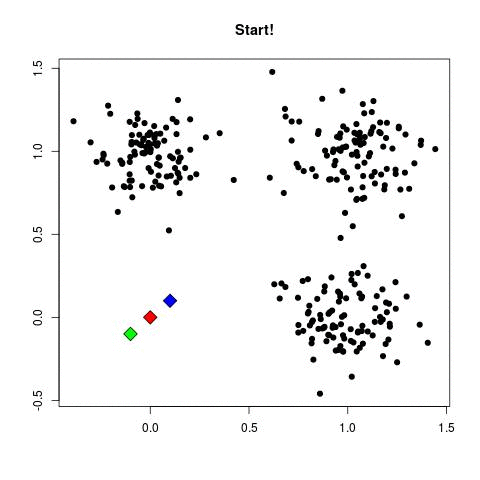

**Key parameters**

- **`n_clusters` (k):** Number of clusters (you must choose it).
- **`n_init`:** Number of random initializations of centroid; The best final solution is retained.
- **`random_state`**: makes the random initialisation reproducible.
- **`max_iter`:** the maximum number of centroid-update iterations in one run. The default value is usually sufficient.


**When to use it:** Roughly **spherical**, **similar-sized** clusters; fast on large **n**; you are OK specifying **k** (or estimating it with **elbow** / domain knowledge).

Let’s have a look at what happens when we apply K-means to the same data using different values of k.

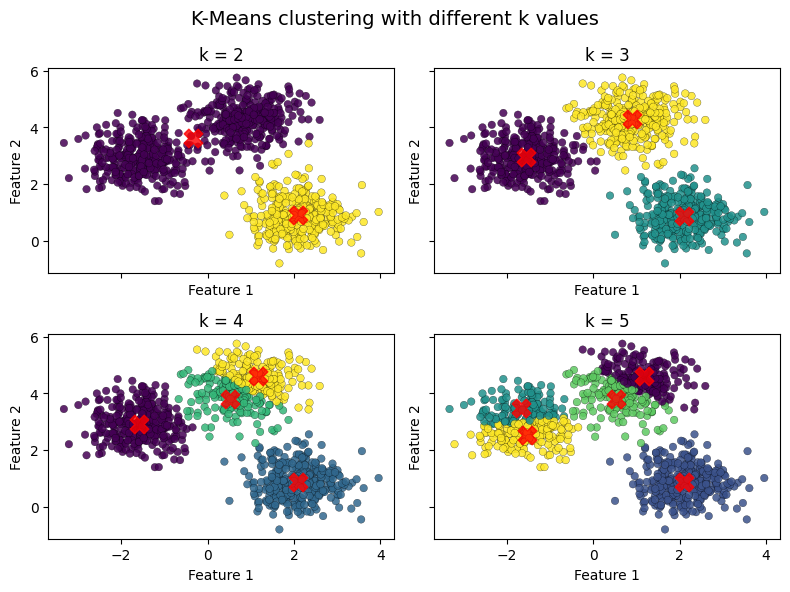

In [76]:
# Visual comparison across multiple k values (2x2 layout)
k_values = [2, 3, 4, 5]
wcss = []
silhouette_scores = []
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
fig.suptitle('K-Means clustering with different k values', fontsize=14)

for ax, k in zip(axs.ravel(), k_values):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    # Calculate WCSS
    wcss.append(kmeans.inertia_)

     # Calculate Silhouette score
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

    # Plot clusters
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=30, 
        edgecolors="k", linewidths=0.2, alpha=0.85)
    # Plot centroids
    centers = kmeans.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], c="red", s=180, marker="X", alpha=0.8)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## How to Choose an Appropriate Number of Clusters?

- ###  **Inertia and the Elbow Method**

**Inertia**, also called the **Within-Cluster Sum of Squares (WCSS)**,
is the sum of the squared distances between each observation and the centroid of its assigned cluster
=> measures how close the points in each cluster are to the cluster center (centroid).

Interpretation:

- Lower inertia → points are close to their centroid → compact clusters
- High inertia → points are far from centroid → poor clustering

If we increase the number of clusters (k), inertia always decreases!<br>
Because of that, we use the **Elbow Method** to choose the optimal number of clusters.

Idea of the elbow method:
- compute inertia for different k
- plot inertia against `k`,
- look for a point where the decrease slows down
- that point is the "elbow"

- ### **Silhouette score**

The Silhouette score measures how well each point fits into its cluster. ¨
It evaluates both: 

- **cohesion** — how close an observation is to other observations in its own
  cluster,
- **separation** — how far it is from the nearest alternative cluster.

For each point:
- compute mean distance to points in the same cluster (a)
- compute mean distance to the nearest other cluster (b)

Silhouette = (b − a) / max(a, b)

Silhouette score is **average over all points.**

Score **ranges from -1 to 1**. Higher score → better separated and more compact clusters


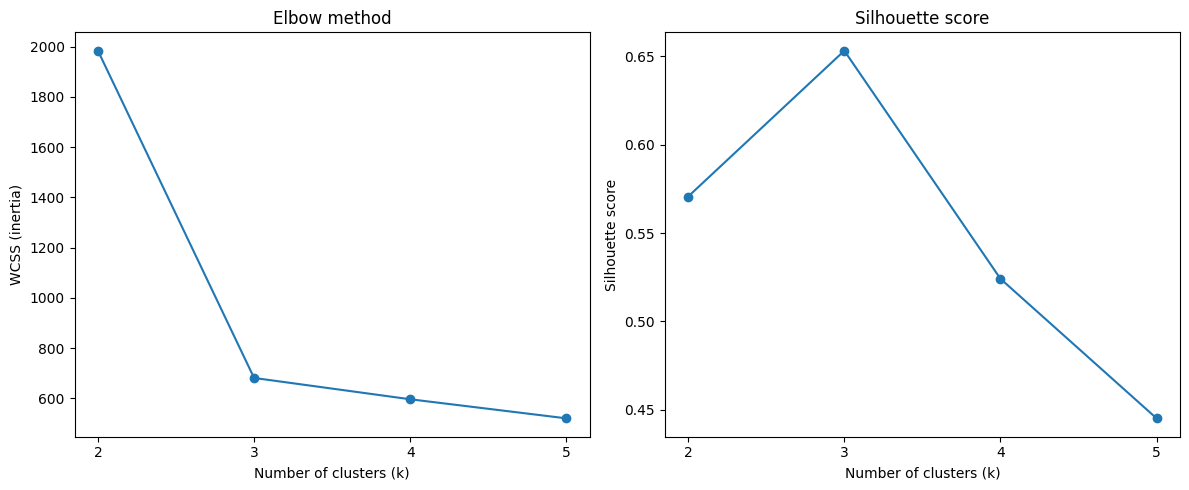

In [74]:
# Elbow and Silhouette plots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
axs[0].plot(k_values, wcss, "-o")
axs[0].set_title("Elbow method")
axs[0].set_xlabel("Number of clusters (k)")
axs[0].set_ylabel("WCSS (inertia)")
axs[0].set_xticks(k_values)

# Silhouette plot
axs[1].plot(k_values, silhouette_scores, "-o")
axs[1].set_title("Silhouette score")
axs[1].set_xlabel("Number of clusters (k)")
axs[1].set_ylabel("Silhouette score")
axs[1].set_xticks(k_values)

plt.tight_layout()
plt.show()

> On real data, the answer is often less clear. Statistical measures help us compare solutions, but the final choice should also be interpretable and useful for the analytical goal.

---

## 🧩 Task 1 : Palmer Penguins 🐧
 
**Analytical question:**  Can physical measurements reveal natural groups among penguins without using their species labels?    

The Palmer Penguins dataset contains physical measurements of penguins observed in the Palmer Archipelago, Antarctica.   
Each row represents one penguin. We will cluster penguins using four physical measurements. The known species will be hidden during clustering and used only afterwards to help interpret the result.

It includes the following features:
- `culmen_length_mm`: Beak length (mm)
- `culmen_depth_mm`: Beak depth (mm)
- `flipper_length_mm`: Flipper length (mm)
- `body_mass_g`: Body mass (g)
- `sex`: Penguin sex (MALE/FEMALE)



### Step 1 - Load and Inspect the Data

In [ ]:
penguins = sns.load_dataset("penguins")

- Display the first rows and inspect the shape and basic information of the dataset.

In [ ]:
# Display the first rows


In [ ]:
# Inspect the number of rows and columns and the column data types


### Step 2 — Select features 
We are goning to define a list of the features we want to cluster based on.  
We will use four numerical measurements:

In [27]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

❓ Why is `species` not included in features?  
❓ Why are categorical columns such as `island` and `sex` not included?

### Step 3 — Check and handle missing values

K-means cannot work with missing values. Count missing values in the selected features, then create `penguins_complete` containing only rows with all four measurements. Do not modify the original DataFrame.

In [ ]:
# Count missing values in the selected features


In [ ]:
# Create penguins_complete/if there is a null or missing values,just drop the row

### Step 4 — Create the feature matrix

A **feature matrix** contains the variables that the algorithm will use. Rows are observations and columns are features.

In [ ]:
# X from penguins_complete and the selected features
X = None  # Replace None with your code

X.head()

In [ ]:
print("Original observations:", len(penguins))
print("Observations used:", len(X))
X.agg(["min", "max"]).round(1)

### Step 5— Scale the features ⚖️

K-means is based on distances. `body_mass_g` has a much larger numerical range than the measurements in millimetres and would otherwise dominate the distance calculation.

Use `StandardScaler` to create `X_scaled`.

In [33]:
# Create scaler and X_scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
print("Means:", X_scaled.mean(axis=0).round(2))
print("Standard deviations:", X_scaled.std(axis=0).round(2))

Means: [ 0. -0. -0.  0.]
Standard deviations: [1. 1. 1. 1.]


❓ Why is scaling important for K-means?   
❓ Does scaling change which penguin has the largest body mass?

### Step 6 — Fit an initial model

Start with `k = 3`. This is an initial choice, not yet a justified final decision.

In [ ]:
# Create a KMeans model with k=3, n_init=10 and random_state=42
kmeans = KMeans(
)
# Fit it to X_scaled and store the labels in cluster_labels
cluster_labels = kmeans.fit_predict(X_scaled) 

In [ ]:
penguins_complete["cluster"] = cluster_labels
penguins_complete["cluster"].value_counts().sort_index()

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=penguins_complete,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="cluster",
    palette="Set1",
    alpha=0.75
)
plt.title("Initial K-means Clusters")
plt.show()

❓ What do cluster labels 0, 1, and 2 mean?  
❓ The model used four features, but the plot shows only two.   Why should this plot not be treated as a complete view of the clustering?

### Step 7 — Compare Different Values of K
- Inertia measures the within-cluster sum of squared distances. Lower values indicate more compact clusters, but inertia always decreases as k increases.
- The silhouette score compares cohesion within clusters with separation between clusters. Higher values indicate better-separated clusters.

In [ ]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set(title="Elbow Method",xlabel="Number of clusters (k)", ylabel="Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o")
axes[1].set(title="Silhouette Scores",xlabel="Number of clusters (k)", ylabel="Silhouette score")

for ax in axes:
    ax.set_xticks(list(k_values))

plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
}).round(3)

❓ Which k is suggested by the elbow method?  
❓ Which k has the highest silhouette score?  
❓ If the methods suggest different values, what other consideration could guide the final choice?

### Step 8 — Fit and interpret the final model

For comparison with the three known species, we will inspect the `k = 3` solution. This does not mean that `k = 3` must have the highest silhouette score.

In [41]:
selected_k = 3

final_model = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

penguins_complete["cluster"] = final_model.fit_predict(X_scaled)

In [ ]:
centres_original = scaler.inverse_transform(
    final_model.cluster_centers_
)

cluster_profiles = pd.DataFrame(
    centres_original,
    columns=features
).round(1)

cluster_profiles

❓ Describe each cluster using its physical measurements rather than only its number. Give each group an informal, meaningful profile.

Compare Clusters with Known Species

In [ ]:
pd.crosstab(
    penguins_complete["cluster"],
    penguins_complete["species"],
    margins=True
)

❓ Do the clusters correspond exactly to the three species?  
❓ Does disagreement with the species labels automatically mean that the clustering is wrong

---
## 3. Independent Investigation: Wine Data 🍷

Apply the same workflow to a second real-world dataset.

**Analytical question**: Can chemical measurements reveal groups of wines without using their known cultivar classes?

The dataset contains 13 numerical chemical measurements and a separately stored known class for each wine.  
Each row represents one wine sample.  
  
The known label is included only so that we can compare it with the clusters after the unsupervised analysis.  

### Step 1 — Load the dataset

`load_wine()` returns a dataset object rather than one ordinary DataFrame:

- `wine_data.data` contains the 13 input features,
- `wine_data.target` contains the known cultivar class,
- `wine_data.target_names` contains the class names.

The known class must not be included in the feature matrix used by K-means.

In [ ]:
from sklearn.datasets import load_wine
wine_data = load_wine(as_frame=True)
X_wine = wine_data.data.copy()
known_labels = wine_data.target.copy()

In [ ]:
print("Feature matrix shape:", X_wine.shape)
print("Known labels shape:", known_labels.shape)
print("Known target names:", wine_data.target_names)
print("Missing feature values:", X_wine.isna().sum().sum())

X_wine.head()

### Step 2 — Inspect and scale the features

Use suitable code to inspect the ranges of the 13 features. Then standardise `X_wine` and store the result in `X_wine_scaled`.

In [ ]:
# Inspect feature ranges. Compare the minimum, maximum and mean of each chemical feature

In [ ]:
# Create wine_scaler and X_wine_scaled



In [ ]:
print("Means:", X_wine_scaled.mean(axis=0).round(2))
print("Standard deviations:", X_wine_scaled.std(axis=0).round(2))

### Step 3 — Evaluate candidate values of k

For each `k` from 2 to 6:

1. fit K-means to the scaled feature matrix,
2. store its inertia,
3. calculate and store its silhouette score,
4. present the results in a table and in two plots.

You may reuse and adapt the Penguins code.

In [ ]:
# Evaluate k = 2, ..., 6

In [ ]:
# Create an evaluation table and plot inertia and silhouette score
wine_evaluation = pd.DataFrame({
    "k": list(wine_k_values),
    "inertia": wine_inertias,
    "silhouette_score": wine_silhouettes
})

print(wine_evaluation.round(3).to_string(index=False))

# Plot both criteria
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wine_evaluation["k"], wine_evaluation["inertia"], marker="o")
axes[0].set(title="Elbow Method", xlabel="Number of clusters (k)", ylabel="Inertia")

axes[1].plot(wine_evaluation["k"], wine_evaluation["silhouette_score"], marker="o")
axes[1].set(title="Silhouette Scores", xlabel="Number of clusters (k)", ylabel="Silhouette score")

plt.tight_layout()
plt.show()

### Step 4 — Fit the final model

Fit your selected model. Create `wine_results` from the original feature matrix and add both the cluster labels and known classes.

In [ ]:
# Set selected_k and create final_wine_model



wine_clusters=

# Create wine_results and add columns named cluster and known_class. Keep inputs, discovered clusters and known classes together for interpretation
wine_results = X_wine.copy()
wine_results["cluster"] = wine_clusters
wine_results["known_class"] = known_labels.to_numpy()

wine_results["cluster"].value_counts().sort_index()

### Step 5 — Interpret and compare

Create a heatmap of the centroids in standardised units. Positive values mean that a cluster is above the overall mean for that feature; negative values mean that it is below the overall mean.

In [ ]:
# Create a centroid DataFrame and display it as a heatmap
# Centroids remain in the standardised feature space
wine_centroid_profiles = pd.DataFrame(
    final_wine_model.cluster_centers_,
    columns=X_wine.columns)

plt.figure(figsize=(13, 4))
sns.heatmap(wine_centroid_profiles,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".1f")
plt.title("Standardised Wine Cluster Profiles")
plt.xlabel("Chemical feature")
plt.ylabel("Cluster")
plt.show()

❓ Which features most clearly distinguish the clusters?

❓ Describe at least two clusters using their above- and below-average measurements.

In [ ]:
# Compare the discovered clusters with the known classes using a crosstab

Create one two-dimensional scatter plot showing the discovered clusters. Choose two features that appear useful from the centroid profiles.

Remember: the model used all 13 features, whereas the scatter plot can show only two.

In [ ]:
# Create a scatter plot coloured by cluster

❓ Are the features measured on comparable numerical scales?  
❓ Which features could dominate Euclidean distance if the original values were used?

❓ Where do you observe an elbow?  
❓ Which value of k has the highest silhouette score?  
❓ Do both methods support the same choice?  

❓ Which features most clearly distinguish the clusters?  
❓ Describe at least two clusters using their above- and below-average measurements.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=wine_results,
    x="alcohol",
    y="proline",
    hue="cluster",
    palette="Set1",
    alpha=0.75,
    ax=axes[0]
)

axes[0].set_title("K-means Clusters")

sns.scatterplot(
    data=wine_results,
    x="alcohol",
    y="proline",
    hue="target",
    palette="Set2",
    alpha=0.75,
    ax=axes[1]
)

axes[1].set_title("Known Wine Classes")

plt.tight_layout()
plt.show()

❓ Do the clusters correspond exactly to the known wine classes?  
❓ Which known classes are most frequently mixed?  
❓ Why is this comparison not the same as training a supervised classification model?

💡 Reminder
There is no guarantee that K-means will reproduce the known labels. The result depends on the selected features, scaling, distance measure, algorithm assumptions, and chosen value of k.

💡 Different scaling methods can also produce different clustering results because they change the distances between observations differently. You do not currently compare them—and that is fine for this introductory exercise.
For example:
- `StandardScaler` uses the mean and standard deviation.
- `MinMaxScaler` maps each feature, usually, to the interval [0, 1].
- `RobustScaler` uses the median and IQR and is less influenced by extreme values.

---

## Exit Ticket

Answer briefly:

1. Why must features usually be scaled before K-means?
2. Why can we not select `k` by choosing the model with the lowest inertia?
3. What does a high silhouette score suggest?
4. Why are cluster labels such as 0 and 1 not ordered categories?
5. Name one situation in which K-means may produce a misleading result.

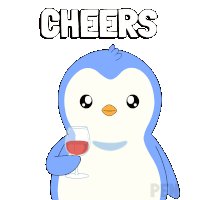